In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

from sklearn.datasets import load_breast_cancer

In [2]:
# cargamos el dataset 
df = load_breast_cancer()
print(df.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [3]:
x = df['data']
x.shape

(569, 30)

In [4]:
'''maligno 1 , venigno 0 '''
y = df['target']
y.shape 

(569,)

In [5]:
# distribucion de clases , para ver si hay balance o no 
y_ser = pd.Series(y)
tabla = y_ser.value_counts()
tabla = tabla.sort_index()

<Axes: xlabel='x', ylabel='y'>

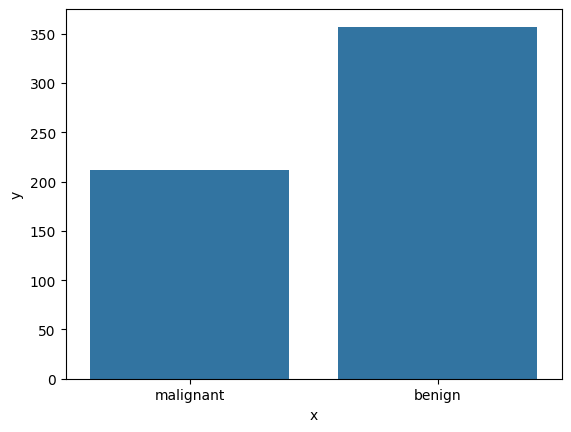

In [6]:
datos = {'x' :list(df['target_names']),'y':tabla.values}
sns.barplot(x='x', y = 'y', data=datos)

In [7]:
y_inv = 1-df['target'] # 1 - evento de interes 
label = list(df['target_names'])
label.reverse()
print(label)

[np.str_('benign'), np.str_('malignant')]


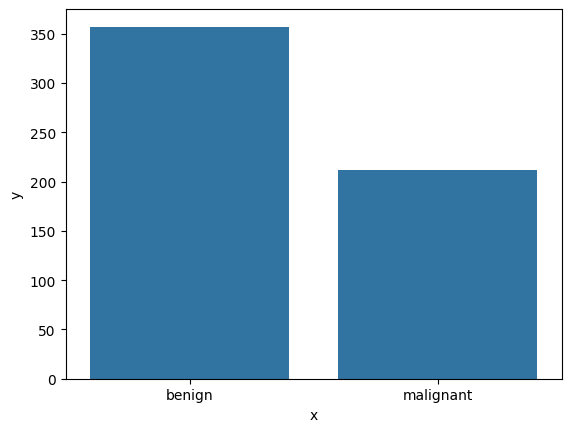

In [8]:
y_sinv = pd.Series(y_inv)
tabla_inv = y_sinv.value_counts()
tabla_inv = tabla_inv.sort_index()
datos_inv = {'x':label,'y': tabla_inv.values}
sns.barplot(x='x',y='y', data= datos_inv)
plt.show()



In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y_inv,test_size=0.3,random_state=0)

In [13]:

model = LogisticRegression(solver = 'liblinear',max_iter=200)
model.fit(x_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
##calculo de predicciones para obtener la matriz de confucion 
y_pred= model.predict(x_test)
matriz_confusion = confusion_matrix(y_test,y_pred)
print(matriz_confusion)

[[103   5]
 [  1  62]]


In [16]:
##interes en falsos negativos

accuracy = accuracy_score (y_test, y_pred)
print(f'Accuracy : {accuracy}')
recall = recall_score(y_test,y_pred)
print(f'Recall: {recall}')
precision = precision_score(y_test,y_pred)
print(f'Precision {precision}')
f1 = f1_score(y_test,y_pred)
print(f'F1 Score: {f1}')

Accuracy : 0.9649122807017544
Recall: 0.9841269841269841
Precision 0.9253731343283582
F1 Score: 0.9538461538461539


In [ ]:
#probabilidad de la malignidad para cada uno de los pacientes 
y_pred_prob = model.predict_proba(x_test)[:,1] 
y_pred_prob

array([9.92748287e-01, 3.15082571e-02, 2.94167568e-03, 2.04414230e-01,
       1.11130696e-04, 3.77432588e-03, 9.86629154e-03, 2.17712023e-03,
       4.14479599e-02, 3.34310763e-04, 4.94840890e-01, 1.55929749e-01,
       5.31947180e-03, 7.72336040e-01, 2.55490569e-01, 9.90926827e-01,
       2.18579794e-02, 9.99999995e-01, 9.98236491e-01, 1.00000000e+00,
       9.99970856e-01, 9.12243525e-01, 2.22191913e-03, 1.38627495e-02,
       9.90774591e-01, 1.44969653e-02, 2.85134449e-03, 8.36795202e-01,
       4.13628590e-03, 1.00000000e+00, 5.54317400e-04, 9.99999943e-01,
       4.12350263e-01, 9.99281908e-01, 3.05335958e-04, 9.98309887e-01,
       9.72959269e-02, 9.99997082e-01, 5.31647001e-03, 9.99564733e-01,
       9.31507655e-01, 7.09135709e-03, 9.97094578e-01, 1.24916218e-03,
       9.57010847e-01, 1.00000000e+00, 4.59788069e-04, 3.16848860e-02,
       1.52923867e-03, 9.99632610e-01, 9.99996274e-01, 7.37298711e-01,
       9.99999145e-01, 5.84593801e-03, 1.13887764e-02, 1.32323009e-03,
      

In [ ]:
## el ajuste del umbral redujo los falsos negativos 
umbral = 0.7 
y_pred_umbral = (y_pred_prob >= umbral).astype(int)

matriz_confucion_umbral = confusion_matrix(y_test,y_pred_umbral)
print('Matriz de confusión (Umbral) : ')
print(matriz_confucion_umbral)

Matriz de confusión (Umbral) : 
[[106   2]
 [  1  62]]


In [19]:

accuracy = accuracy_score (y_test, y_pred_umbral)
print(f'Accuracy : {accuracy}')
recall = recall_score(y_test,y_pred_umbral)
print(f'Recall: {recall}')
precision = precision_score(y_test,y_pred_umbral)
print(f'Precision {precision}')
f1 = f1_score(y_test,y_pred_umbral)
print(f'F1 Score: {f1}')

Accuracy : 0.9824561403508771
Recall: 0.9841269841269841
Precision 0.96875
F1 Score: 0.9763779527559056


In [ ]:
#busqueda en grip de hiperamatros 

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.datasets import load_iris


In [26]:
df = load_iris()
x = df['data']
y = df['target']

In [27]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=1234)


In [ ]:
#busqueda en grip 
c_grid = 0.02*np.arange(1,20) 
gamma_grid = 0.02*np.arange(1,50)
param_grid = {'C':c_grid, 'gamma': gamma_grid}
gridCV = GridSearchCV(
    SVC(kernel = 'rbf'),
    param_grid,
    cv=5,
    #scoring='f1' 
    n_jobs=-1
)
gridCV.fit(x_train,y_train)
best_C = gridCV.best_params_['C']
best_gamma = gridCV.best_params_['gamma']



In [36]:
print('Meor gamma:',best_gamma)
print('Mejor C:',best_C )
print('Mejor Score:',gridCV.best_score_)

Meor gamma: 0.86
Mejor C: 0.12
Mejor Score: 0.9714285714285713


In [38]:
SVM_b = SVC(kernel='rbf', C=best_C,gamma = best_gamma)
SVM_b.fit(x_train,y_train)
y_pred_b = SVM_b.predict(x_test)
print('SVM con mejores hiperparametros '+str(np.round(accuracy_score(y_test,y_pred_b),4)))

SVM con mejores hiperparametros 0.9778
